In [1]:
import pandas as pd
import numpy as np

In [4]:
from src.preprocess import load_dataset

ModuleNotFoundError: No module named 'src'

In [ ]:
df = load_dataset("dataset/spam.csv")

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5169 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5169 non-null   object
 1   message  5169 non-null   object
dtypes: object(2)
memory usage: 121.1+ KB


In [10]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


>**Preprocess**

In [11]:
df = df.drop(columns=['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'])

In [12]:
df = df.rename(columns={
    'v1': 'label',
    'v2': 'message'
})

In [13]:
print(df.isnull().sum())

label      0
message    0
dtype: int64


In [17]:
print(df['message'].duplicated().sum())

403


In [15]:
df = df.drop_duplicates()

In [41]:
df["label"].value_counts()

label
0    4516
1     653
Name: count, dtype: int64

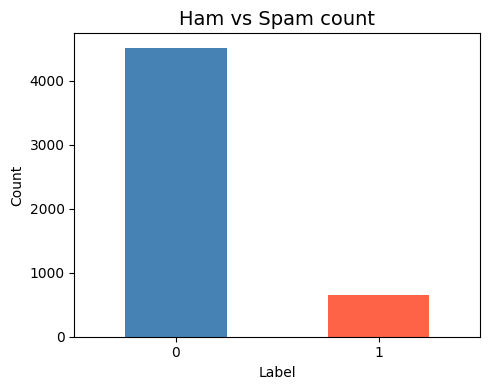

In [39]:
fig, ax = plt.subplots(figsize=(5, 4))
df["label"].value_counts().plot(kind="bar", color=["steelblue", "tomato"], ax=ax)
ax.set_title("Ham vs Spam count", fontsize=14)
ax.set_xlabel("Label")
ax.set_ylabel("Count")
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

In [17]:
df['label'] = df['label'].map({'ham': 0, 'spam': 1})

In [18]:
df['message'] = df['message'].str.lower()

In [19]:
import string

df['message'] = df['message'].apply(
    lambda x: x.translate(str.maketrans('', '', string.punctuation))
)

In [20]:
from nltk.tokenize import word_tokenize

df['tokens'] = df['message'].apply(word_tokenize)

In [21]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

df['tokens'] = df['tokens'].apply(
    lambda words: [word for word in words if word not in stop_words]
)

In [22]:
from nltk.stem import PorterStemmer

ps = PorterStemmer()

df['tokens'] = df['tokens'].apply(
    lambda words: [ps.stem(word) for word in words]
)

In [23]:
df['clean_message'] = df['tokens'].apply(lambda x: " ".join(x))

#Vectorisation

In [24]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df['clean_message'])
y = df['label']

In [62]:
df['clean_message']

0       go jurong point crazi avail bugi n great world...
1                                   ok lar joke wif u oni
2       free entri 2 wkli comp win fa cup final tkt 21...
3                     u dun say earli hor u c alreadi say
4               nah dont think goe usf live around though
                              ...                        
5567    2nd time tri 2 contact u u å£750 pound prize 2...
5568                              ì b go esplanad fr home
5569                              piti mood soani suggest
5570    guy bitch act like id interest buy someth els ...
5571                                       rofl true name
Name: clean_message, Length: 5169, dtype: object

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [42]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train, y_train = smote.fit_resample(X_train, y_train)

print(y_train.value_counts())

label
0    3627
1    3627
Name: count, dtype: int64


In [43]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from xgboost import XGBClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

#Navie Bayes

In [46]:
nb = MultinomialNB()

nb.fit(X_train, y_train)

nb_pred = nb.predict(X_test)

print("Naive Bayes Accuracy:", accuracy_score(y_test, nb_pred))
print(classification_report(y_test, nb_pred))

Naive Bayes Accuracy: 0.9671179883945842
              precision    recall  f1-score   support

           0       0.99      0.98      0.98       889
           1       0.86      0.92      0.89       145

    accuracy                           0.97      1034
   macro avg       0.92      0.95      0.93      1034
weighted avg       0.97      0.97      0.97      1034



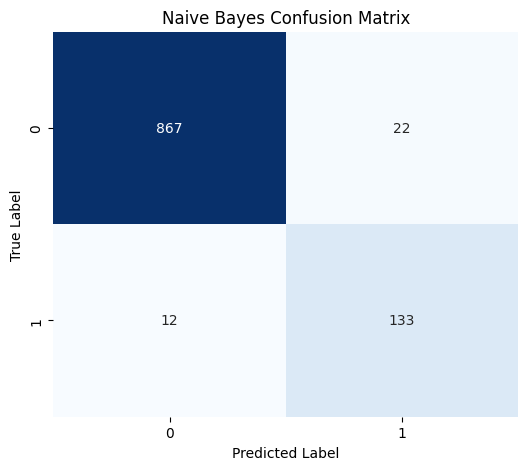

In [47]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, nb_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Naive Bayes Confusion Matrix")

plt.show()

#SVM

In [48]:
svm = LinearSVC(random_state=42)

svm.fit(X_train, y_train)

svm_pred = svm.predict(X_test)

print("SVM Accuracy:", accuracy_score(y_test, svm_pred))
print(classification_report(y_test, svm_pred))

SVM Accuracy: 0.9758220502901354
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       889
           1       0.95      0.88      0.91       145

    accuracy                           0.98      1034
   macro avg       0.96      0.93      0.95      1034
weighted avg       0.98      0.98      0.98      1034



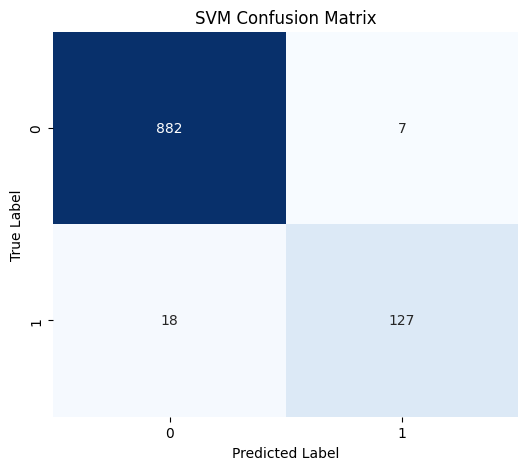

In [49]:
cm = confusion_matrix(y_test, svm_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("SVM Confusion Matrix")

plt.show()

#XGBoost

In [50]:
xgb = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

print("XGBoost Accuracy:", accuracy_score(y_test, xgb_pred))
print(classification_report(y_test, xgb_pred))

XGBoost Accuracy: 0.9632495164410058
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       889
           1       0.87      0.86      0.87       145

    accuracy                           0.96      1034
   macro avg       0.93      0.92      0.92      1034
weighted avg       0.96      0.96      0.96      1034



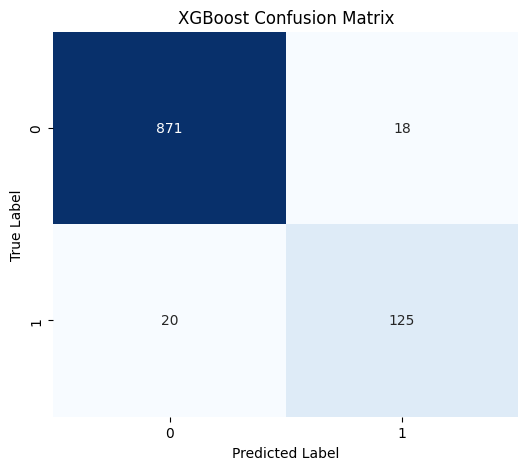

In [51]:
cm = confusion_matrix(y_test, xgb_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("XGBoost Confusion Matrix")

plt.show()

#ADABoost

In [52]:
ada = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=100,
    learning_rate=1.0,
    random_state=42
)

ada.fit(X_train, y_train)

ada_pred = ada.predict(X_test)

print("AdaBoost Accuracy:", accuracy_score(y_test, ada_pred))
print(classification_report(y_test, ada_pred))

AdaBoost Accuracy: 0.9187620889748549
              precision    recall  f1-score   support

           0       0.96      0.94      0.95       889
           1       0.69      0.76      0.72       145

    accuracy                           0.92      1034
   macro avg       0.83      0.85      0.84      1034
weighted avg       0.92      0.92      0.92      1034



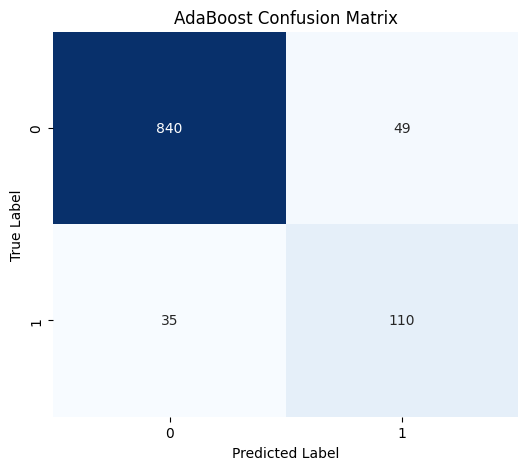

In [53]:
cm = confusion_matrix(y_test, ada_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("AdaBoost Confusion Matrix")

plt.show()

#comparision

In [54]:
results = {
    "Naive Bayes": accuracy_score(y_test, nb_pred),
    "SVM": accuracy_score(y_test, svm_pred),
    "XGBoost": accuracy_score(y_test, xgb_pred),
    "AdaBoost": accuracy_score(y_test, ada_pred)
}

for model, acc in results.items():
    print(f"{model}: {acc:.4f}")

Naive Bayes: 0.9671
SVM: 0.9758
XGBoost: 0.9632
AdaBoost: 0.9188


In [55]:
comparison = pd.DataFrame({
    "Algorithm": results.keys(),
    "Accuracy": results.values()
})

comparison = comparison.sort_values(by="Accuracy", ascending=False)

print(comparison)

     Algorithm  Accuracy
1          SVM  0.975822
0  Naive Bayes  0.967118
2      XGBoost  0.963250
3     AdaBoost  0.918762


In [56]:
import pickle

with open("spam_model.pkl", "wb") as file:
    pickle.dump(svm, file)

print("Model saved successfully!")

Model saved successfully!


In [57]:
with open("tfidf_vectorizer.pkl", "wb") as file:
    pickle.dump(tfidf, file)

print("Vectorizer saved successfully!")

Vectorizer saved successfully!


In [58]:
import pickle

with open("spam_model.pkl", "rb") as file:
    model = pickle.load(file)

with open("tfidf_vectorizer.pkl", "rb") as file:
    tfidf = pickle.load(file)

In [59]:
message = ["Congratulations! You have won a free iPhone. Click here now!"]

message_vector = tfidf.transform(message)

prediction = model.predict(message_vector)

if prediction[0] == 1:
    print("Spam")
else:
    print("Not Spam")

Spam
